In [1]:
from google.colab import files
files.upload()

Saving eor dataset.zip to eor dataset.zip


{'eor dataset.zip': b'PK\x03\x04-\x00\x00\x08\x08\x00<|{Z\xd2\xc8u\xea\xff\xff\xff\xff\xff\xff\xff\xff\x16\x00\x14\x00synthetic_oil_data.csv\x01\x00\x10\x00w`\x07\x00\x00\x00\x00\x00\x03<\x03\x00\x00\x00\x00\x00d\xdd\xdb\xae,\xebu$\xe6{=K\xa1\x90\xe7\xc3\xa5\x81v_\x19\xb6\xd0\xea{\x82-\x11h\xc2\xa4(P\xb4\xe1~{\xc7\x17\xb9fUe-\x81\xda\xe4^k\xce\xaa\xcc\xff0\x0e1b\xc4\xf8o\x7f\xfb\xd7\xff\xfb\x0f\xff\xfd\x7f\xfd\xc7\x9f\x1e\xff\xfc\xb7\xbf\xff\xed?\xff\xfc\x8f\xff\xf5\xf8\xe7?\xfd\xfd\xaf\x7f\xfa\xe3\xff\xf8\xf3_\xfc\xcb\x7f\xff\xfb\x1f\xff\xe3\xfa\xfb\x7f\xf9\xd3\x9f\xff\xf3\xaf\x7f\xfe\xd7?\xfc\xcb\xbf\xfe\xed\xef\xf9\xe9\xbf\xff\xed\xff\xfb\xf3_\xf3\x13\x7f\xf8\xc7\xdf\xfe\xf0\x7f\xfd\xf9/\x7f\xf8\xaf\x7f\xfe\xd3_\xfe\xed\xf1\xbf\xff\xe7?\xfe\xfc\xd7?\xfe\xe3O\xff\xf6\x87\xff\xf6\xa7\xff\xfc\xd3\xdf\xff\xdf\xbf\xfd\xf9\xef\x7f\xf8/\x7f\xfa\x8f\x7f\xfc\xcf\x87\x9f\xf9\xe7\xbf\xe7\x0f\xff\xfd_\xff\xf4O\xff\xf2?\xff\xf8\x97?=\x86\xe72\x1f\xc7\xb2\xef\xdb6\xcf\xc3\xb4\x8f\xcb\xfa8\x87\xf9

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("eor dataset.zip")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (5000, 8)

First 5 rows:


,Rock_Type,Porosity,Permeability,Trap_Type,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence
0,Shale,0.438848,903.714252,NaN,0.181881,4.226811,1547,0
1,Sandstone,6.217269,111.883819,Fault,0.169586,0.583624,4878,0
2,Shale,21.397076,177.944336,NaN,0.862800,0.180588,1815,0
3,Shale,11.598605,429.236160,Dome,0.498148,3.042691,1886,0
4,Sandstone,19.874518,127.586022,Anticline,0.245937,1.708715,4420,0


In [12]:
df = pd.read_csv("eor dataset.zip")
df["Trap_Type"] = df["Trap_Type"].fillna("Unknown")

le_rock = LabelEncoder()
le_trap = LabelEncoder()
df["Rock_Type"] = le_rock.fit_transform(df["Rock_Type"])
df["Trap_Type"] = le_trap.fit_transform(df["Trap_Type"])

def assign_eor(row):
    depth = row["Estimated_Reservoir_Depth"]
    por   = row["Porosity"]
    if depth > 3500 and por < 10:
        return "Gas Injection"
    elif 2000 <= depth <= 3500 and por >= 10:
        return "Chemical"
    else:
        return "Waterflood"

df["EOR_Method"] = df.apply(assign_eor, axis=1)

X = df.drop(["Oil_Presence", "EOR_Method"], axis=1)
le_eor    = LabelEncoder()
y         = le_eor.fit_transform(df["EOR_Method"])
eor_names = le_eor.classes_   # ['Chemical', 'Gas Injection', 'Waterflood']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [13]:
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_sc  = scaler.transform(X_test)        # same scaler on test
X_sc       = scaler.transform(X)

In [14]:
print("=" * 55)
print("  METHOD 2 : ARTIFICIAL NEURAL NETWORK (ANN)")
print("=" * 55)
print("  Architecture: Input(7) → 128 → 64 → 32 → Output(3)")
print("  Activation  : ReLU  |  Optimizer: Adam  |  Reg: L2")
print("=" * 55)

  METHOD 2 : ARTIFICIAL NEURAL NETWORK (ANN)
  Architecture: Input(7) → 128 → 64 → 32 → Output(3)
  Activation  : ReLU  |  Optimizer: Adam  |  Reg: L2


In [15]:
ann_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    alpha=0.001,
    batch_size=32,
    learning_rate="adaptive",
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=False
)

ann_model.fit(X_train_sc, y_train)
print(f"\nANN training complete. Epochs used: {ann_model.n_iter_}")

y_pred_ann = ann_model.predict(X_test_sc)
y_prob_ann = ann_model.predict_proba(X_test_sc)
acc_ann    = accuracy_score(y_test, y_pred_ann)


ANN training complete. Epochs used: 45


In [16]:
cv_ann = []
print("\nRunning 5-Fold CV for ANN ...")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_sc, y), 1):
    ann_cv = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32), activation="relu",
        solver="adam", alpha=0.001, batch_size=32,
        learning_rate="adaptive", learning_rate_init=0.001,
        max_iter=300, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=20,
        random_state=42, verbose=False
    )
    ann_cv.fit(X_sc[tr_idx], y[tr_idx])
    fold_acc = accuracy_score(y[val_idx], ann_cv.predict(X_sc[val_idx]))
    cv_ann.append(fold_acc)
    print(f"  Fold {fold} : {fold_acc*100:.2f}%")

cv_ann = np.array(cv_ann)
print(f"\nANN 5-Fold CV Accuracy : {cv_ann.mean()*100:.2f}% ± {cv_ann.std()*100:.2f}%")
print(f"ANN Test Accuracy      : {acc_ann*100:.2f}%")

print("\nANN Classification Report:\n")
print(classification_report(y_test, y_pred_ann, target_names=eor_names))


Running 5-Fold CV for ANN ...
  Fold 1 : 97.90%
  Fold 2 : 98.40%
  Fold 3 : 97.30%
  Fold 4 : 96.20%
  Fold 5 : 99.00%

ANN 5-Fold CV Accuracy : 97.76% ± 0.96%
ANN Test Accuracy      : 97.33%

ANN Classification Report:

               precision    recall  f1-score   support

     Chemical       0.97      0.94      0.96       330
Gas Injection       0.98      0.95      0.96       166
   Waterflood       0.97      0.99      0.98      1004

     accuracy                           0.97      1500
    macro avg       0.97      0.96      0.97      1500
 weighted avg       0.97      0.97      0.97      1500



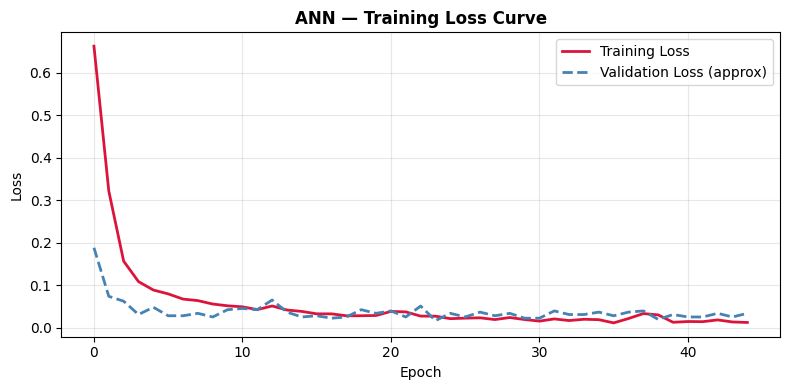

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ann_model.loss_curve_, color="crimson", lw=2, label="Training Loss")
if ann_model.validation_scores_ is not None:
    val_loss = [1 - s for s in ann_model.validation_scores_]
    ax.plot(val_loss, color="steelblue", lw=2,
            linestyle="--", label="Validation Loss (approx)")
ax.set_title("ANN — Training Loss Curve", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

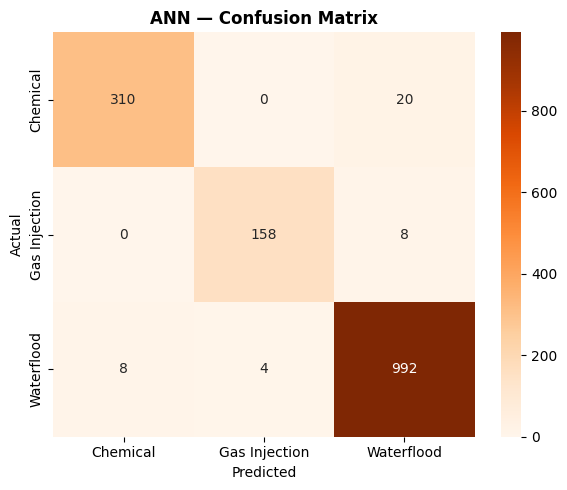

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_ann = confusion_matrix(y_test, y_pred_ann)
sns.heatmap(cm_ann, annot=True, fmt="d", cmap="Oranges",
            xticklabels=eor_names, yticklabels=eor_names, ax=ax)
ax.set_title("ANN — Confusion Matrix", fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

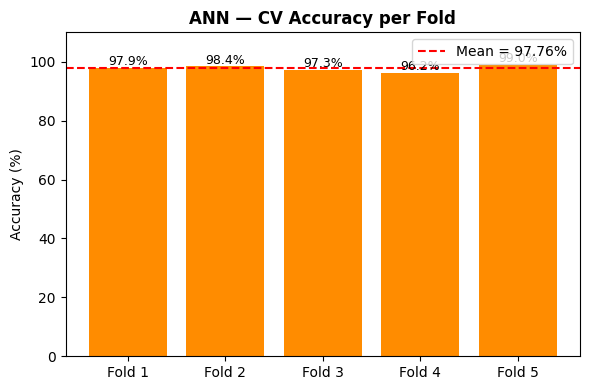

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([f"Fold {i+1}" for i in range(5)], cv_ann * 100, color="darkorange")
ax.axhline(cv_ann.mean() * 100, color="red", linestyle="--",
           label=f"Mean = {cv_ann.mean()*100:.2f}%")
ax.set_title("ANN — CV Accuracy per Fold", fontweight="bold")
ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 110); ax.legend()
for i, v in enumerate(cv_ann):
    ax.text(i, v * 100 + 1, f"{v*100:.1f}%", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

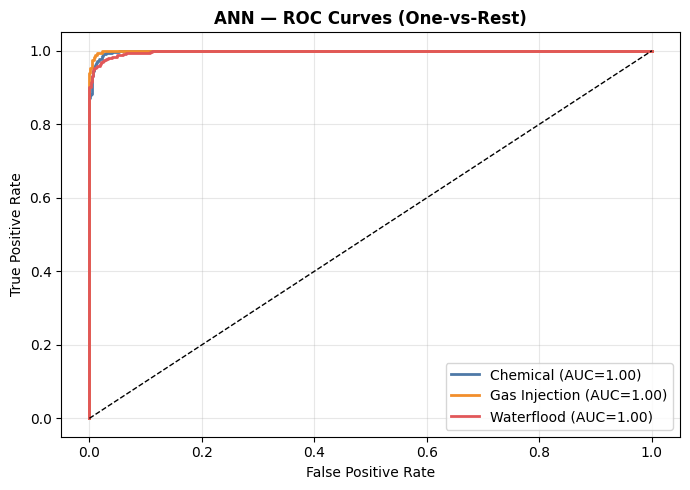

ANN ROC-AUC (macro) : 0.9987


In [20]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
fig, ax = plt.subplots(figsize=(7, 5))
colors_roc = ["#4e79a7", "#f28e2b", "#e15759"]
for i, name in enumerate(eor_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_ann[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_prob_ann[:, i])
    ax.plot(fpr, tpr, lw=2, color=colors_roc[i],
            label=f"{name} (AUC={auc_i:.2f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ANN — ROC Curves (One-vs-Rest)", fontweight="bold")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

auc_ann = roc_auc_score(y_test_bin, y_prob_ann, average="macro")
print(f"ANN ROC-AUC (macro) : {auc_ann:.4f}")

In [21]:
print("\n── ANN Sample Predictions (5 random test rows) ──")
for idx in np.random.choice(len(X_test_sc), 5, replace=False):
    pred   = ann_model.predict(X_test_sc[idx:idx+1])[0]
    prob   = ann_model.predict_proba(X_test_sc[idx:idx+1])[0]
    actual = y_test[idx]
    mark   = "✓" if pred == actual else "✗"
    print(f"  Actual: {eor_names[actual]:15s} | "
          f"Predicted: {eor_names[pred]:15s} | "
          f"Confidence: {prob[pred]*100:.1f}% {mark}")

print("\n" + "=" * 55)
print(f"  ANN Test Accuracy      : {acc_ann*100:.2f}%")
print(f"  ANN 5-Fold CV Accuracy : {cv_ann.mean()*100:.2f}% ± {cv_ann.std()*100:.2f}%")
print(f"  ANN ROC-AUC (macro)    : {auc_ann:.4f}")
print("=" * 55)


── ANN Sample Predictions (5 random test rows) ──
  Actual: Waterflood      | Predicted: Waterflood      | Confidence: 100.0% ✓
  Actual: Waterflood      | Predicted: Waterflood      | Confidence: 100.0% ✓
  Actual: Waterflood      | Predicted: Waterflood      | Confidence: 100.0% ✓
  Actual: Chemical        | Predicted: Waterflood      | Confidence: 95.1% ✗
  Actual: Chemical        | Predicted: Chemical        | Confidence: 100.0% ✓

  ANN Test Accuracy      : 97.33%
  ANN 5-Fold CV Accuracy : 97.76% ± 0.96%
  ANN ROC-AUC (macro)    : 0.9987
